In [5]:

import numpy as np


import pandas as pd

import matplotlib.pyplot as plt


%matplotlib inline

In [6]:
df = pd.read_csv("amazon.csv")

In [7]:
# ex 
print("Rows and Columns:", df.shape)

Rows and Columns: (1465, 16)


In [12]:
#ex 
df.info()
df.columns
df.tail()
df.head()
df.describe()
df.describe(include='all')
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   object 
 6   rating               1465 non-null   object 
 7   rating_count         1463 non-null   object 
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [11]:
df["discounted_price"] = (
    df["discounted_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["actual_price"] = (
    df["actual_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [ ]:
df["discount_percentage"] = (
    df["discount_percentage"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

In [13]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

In [16]:
#numpy analysis 
np.mean(df["actual_price"])
np.max(df["actual_price"])
np.min(df["actual_price"])
np.median(df["actual_price"])
np.std(df["actual_price"])

np.float64(5444.990634812287)

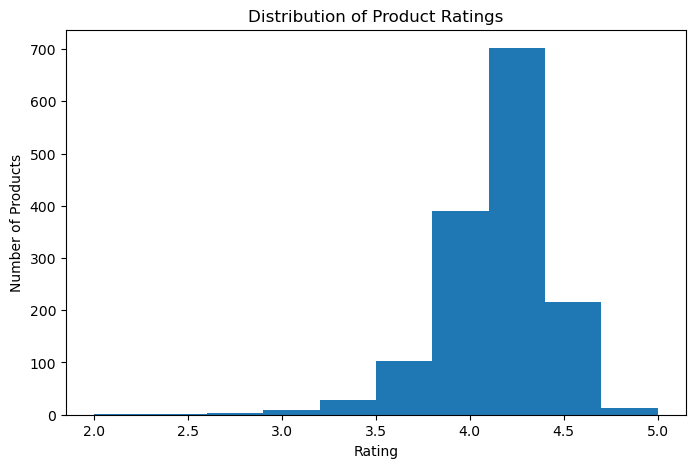

In [20]:
#matplotlib (histogram)
plt.figure(figsize=(8,5))

plt.hist(df['rating'].dropna(), bins=10)

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()



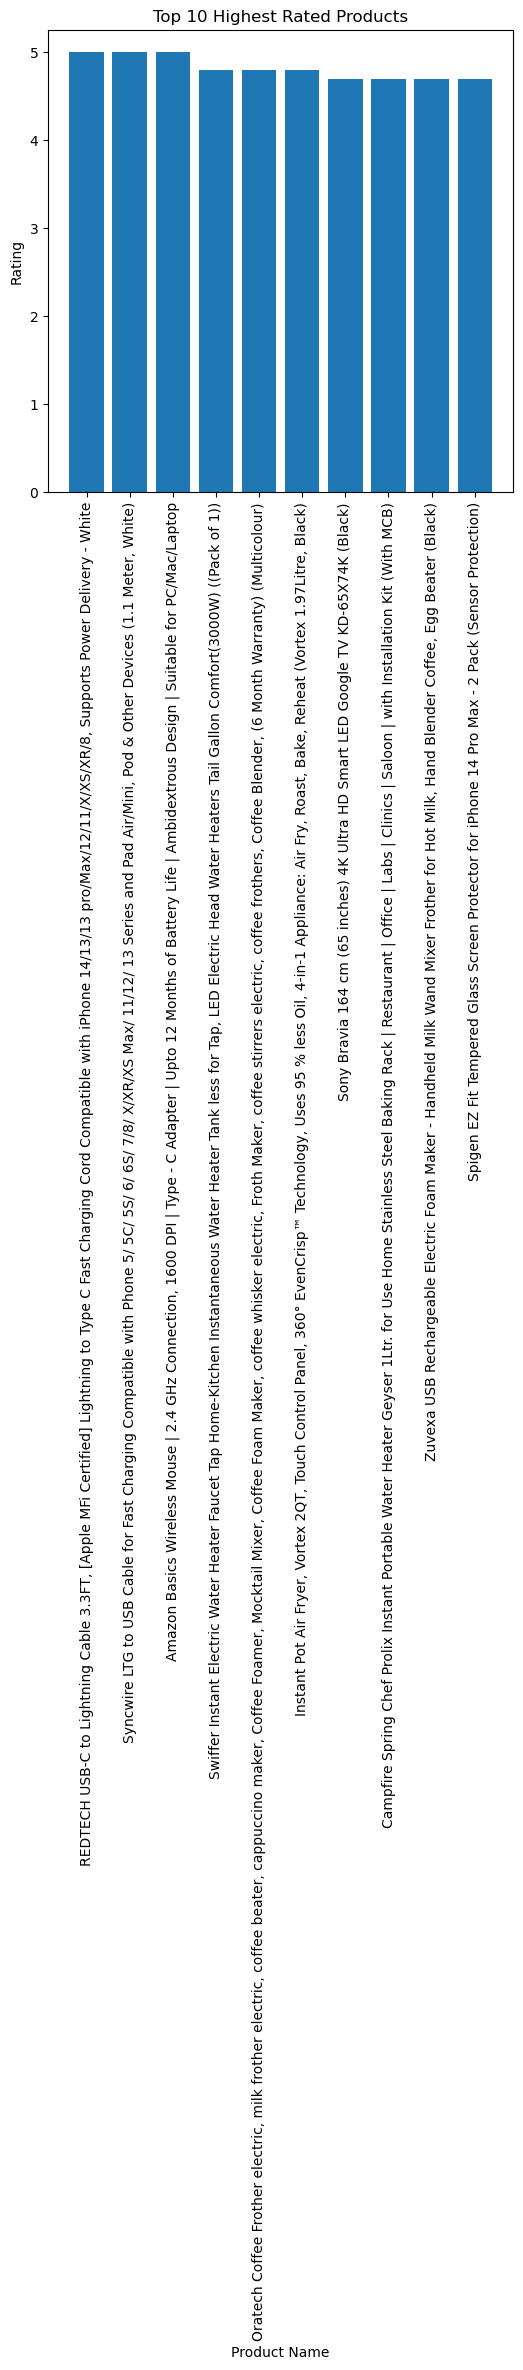

In [24]:
#bar chart -> top 10 products with highest rating 
top10 = df.sort_values(by='rating', ascending=False).head(10)

plt.figure(figsize=(6,6))

plt.bar(top10['product_name'], top10['rating'])

plt.title("Top 10 Highest Rated Products")
plt.xlabel("Product Name")
plt.ylabel("Rating")

plt.xticks(rotation=90)

plt.show()

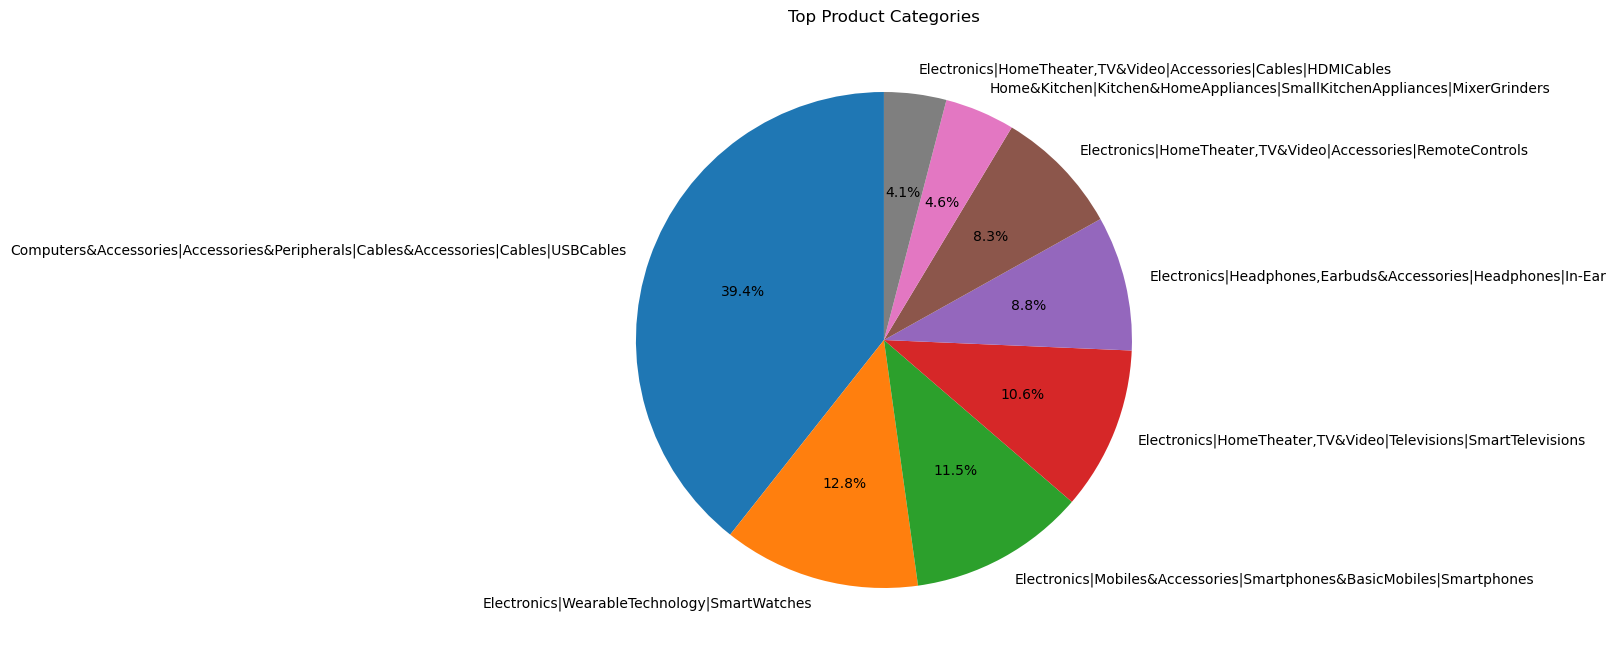

In [26]:
category_count = df['category'].value_counts().head(8)

plt.figure(figsize=(8,8))

plt.pie(category_count,
        labels=category_count.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Top Product Categories")

plt.show()